# MultiResHuBERT — Multi-Resolution Audio Encoder

This notebook visualizes the **MultiResHuBERT** audio encoder
(`stage2_scoring/multires_hubert.py`), an alternative backbone for
`HubertMultiTask` (Stage 2) enabled with `--use_multires_hubert`.

Instead of a single learnable layer-weighted sum over HuBERT's hidden states,
MultiResHuBERT computes **`num_res_streams` independent weighted sums**, each
with its own softmax-normalised layer-weight vector and projection head. The
streams are Gaussian-initialised with peaks spread across the network depth
(low layers ~ acoustic/phonetic detail, high layers ~ semantic/prosodic
information), then concatenated and fused back down to `d_model` — so the rest
of `HubertMultiTask` (pre-fusion self-attention, cross-attention with text,
post-fusion Transformer, scoring heads) is unchanged.

See `notebooks/architecture.ipynb` for the full Stage 1 / Stage 2 pipeline.

> Run from the repo root or from `notebooks/` — the setup cell handles both.

In [2]:
%matplotlib inline
import os, sys

# Make repo-root imports work whether launched from the root or from notebooks/
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import torch
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# One color per role, used consistently across all diagrams
PALETTE = {
    "data":   dict(fc="#fff8e1", ec="#f9ab00"),   # datasets / raw inputs
    "audio":  dict(fc="#e8f0fe", ec="#1a73e8"),   # audio stream
    "text":   dict(fc="#e6f4ea", ec="#188038"),   # text stream
    "fusion": dict(fc="#f3e8fd", ec="#8430ce"),   # fusion / refinement
    "head":   dict(fc="#fce8e6", ec="#d93025"),   # output heads / losses
    "frozen": dict(fc="#f1f3f4", ec="#5f6368"),   # frozen components
}

def box(ax, cx, cy, w, h, label, kind="audio", fs=9, ls="-"):
    c = PALETTE[kind]
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=c["fc"], ec=c["ec"], lw=1.5, linestyle=ls))
    ax.text(cx, cy, label, ha="center", va="center", fontsize=fs)

def arrow(ax, p0, p1, label="", color="#444", ls="-", fs=8, dx=0.12, dy=0.0):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=13,
                                 color=color, lw=1.4, linestyle=ls,
                                 shrinkA=2, shrinkB=2))
    if label:
        ax.text((p0[0]+p1[0])/2 + dx, (p0[1]+p1[1])/2 + dy, label,
                fontsize=fs, color=color, ha="left", va="center")

def canvas(w, h, title, xmax=10, ymax=10):
    fig, ax = plt.subplots(figsize=(w, h))
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax); ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")
    return fig, ax

print("Repo root:", ROOT)

Matplotlib is building the font cache; this may take a moment.


Repo root: c:\Users\Admin\Documents\pronunciation_scoring\pronunciation-scoring


## Architecture

For `num_res_streams = 4` (the default):

- **HuBERT backbone** produces 25 hidden states (1 embedding layer + 24 transformer layers, hidden size 1024 for HuBERT-Large).
- Each of the **4 streams** computes `softmax(layer_weights[s]) · hidden_states` → `(B, T, 1024)`, then its own `Linear(1024 → d_model)`.
- The 4 projected streams are **concatenated** → `(B, T, 4·d_model)` and passed through a fusion `Linear(4·d_model → d_model)`.
- The result `(B, T, d_model)` feeds into the *same* downstream pipeline as the single-stream encoder (pre-fusion self-attention, cross-attention with text, post-fusion Transformer, scoring heads).

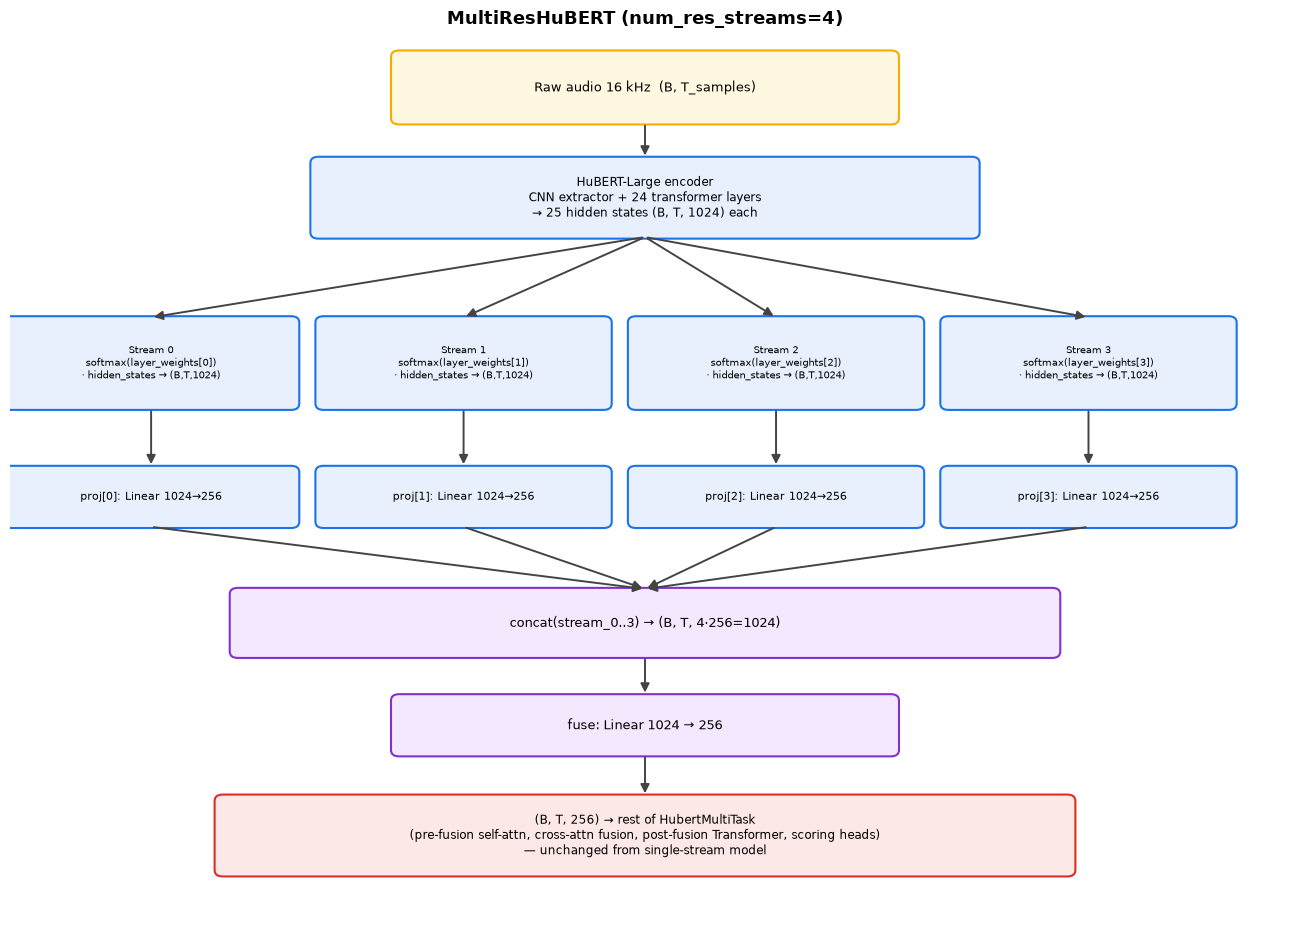

In [3]:
S = 4  # default num_res_streams

fig, ax = canvas(13, 9.5, "MultiResHuBERT (num_res_streams=4)", xmax=12.6, ymax=11.4)

box(ax, 6.3, 10.7, 5.0, 0.9, "Raw audio 16 kHz  (B, T_samples)", "data", 9)
box(ax, 6.3, 9.3, 6.6, 1.0, "HuBERT-Large encoder\nCNN extractor + 24 transformer layers\n→ 25 hidden states (B, T, 1024) each", "audio", 8.5)
arrow(ax, (6.3, 10.25), (6.3, 9.8))

stream_x = [1.4, 4.5, 7.6, 10.7]
for s, cx in enumerate(stream_x):
    box(ax, cx, 7.2, 2.9, 1.15, f"Stream {s}\nsoftmax(layer_weights[{s}])\n· hidden_states → (B,T,1024)", "audio", 7.5)
    box(ax, cx, 5.5, 2.9, 0.75, f"proj[{s}]: Linear 1024→256", "audio", 8)
    arrow(ax, (6.3, 8.8), (cx, 7.78))
    arrow(ax, (cx, 6.62), (cx, 5.88))

box(ax, 6.3, 3.9, 8.2, 0.85, "concat(stream_0..3) → (B, T, 4·256=1024)", "fusion", 9)
for cx in stream_x:
    arrow(ax, (cx, 5.12), (6.3, 4.33))

box(ax, 6.3, 2.6, 5.0, 0.75, "fuse: Linear 1024 → 256", "fusion", 9)
arrow(ax, (6.3, 3.47), (6.3, 2.98))

box(ax, 6.3, 1.2, 8.5, 1.0, "(B, T, 256) → rest of HubertMultiTask\n(pre-fusion self-attn, cross-attn fusion, post-fusion Transformer, scoring heads)\n— unchanged from single-stream model", "head", 8.5)
arrow(ax, (6.3, 2.225), (6.3, 1.7))

plt.tight_layout(); plt.show()

## Gaussian-initialised layer weights

Each stream's `layer_weights[s]` row is initialised with a Gaussian bump centred
on a different layer index (`peaks = linspace(0, n_layers-1, num_streams)`), so
streams start out specialised to different depths before training. Softmax is
applied at runtime — these plots show the *initial* (untrained) per-stream
distributions over the 25 HuBERT-Large hidden states.

c:\Users\Admin\Documents\pronunciation_scoring\pronunciation-scoring\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


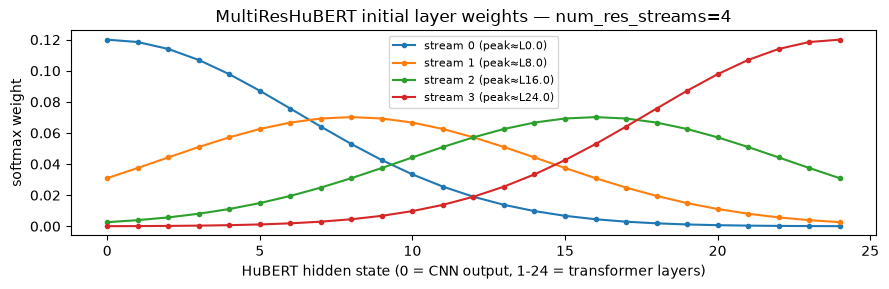

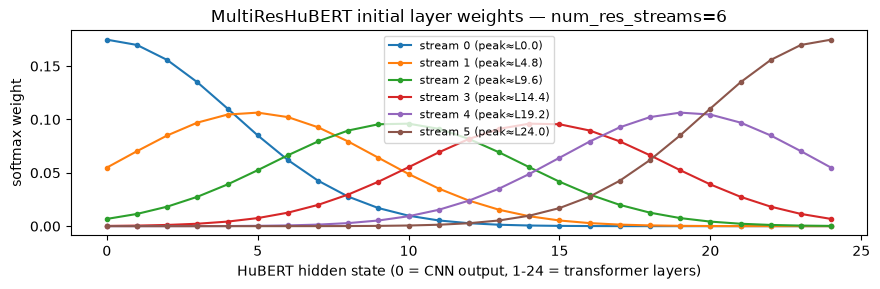

In [4]:
# Reproduce the init from stage2_scoring/multires_hubert.py without downloading
# the full HuBERT checkpoint (only the lightweight config is needed for n_layers).
from transformers import HubertConfig

MODEL_NAME = "facebook/hubert-large-ll60k"
try:
    cfg = HubertConfig.from_pretrained(MODEL_NAME)
    n_layers = cfg.num_hidden_layers + 1
except Exception as e:
    print(f"(offline — could not fetch config: {e}; assuming HuBERT-Large)")
    n_layers = 25

for num_streams in (4, 6):
    layer_idx = torch.arange(n_layers, dtype=torch.float32)
    peaks     = torch.linspace(0, n_layers - 1, num_streams)
    spread    = max(n_layers / num_streams, 1.0)
    init      = -((layer_idx[None, :] - peaks[:, None]) ** 2) / (2 * spread ** 2)
    weights   = torch.softmax(init, dim=-1).numpy()

    fig, ax = plt.subplots(figsize=(9, 3))
    for s in range(num_streams):
        ax.plot(range(n_layers), weights[s], marker="o", ms=3, label=f"stream {s} (peak≈L{peaks[s]:.1f})")
    ax.set_xlabel("HuBERT hidden state (0 = CNN output, 1-24 = transformer layers)")
    ax.set_ylabel("softmax weight")
    ax.set_title(f"MultiResHuBERT initial layer weights — num_res_streams={num_streams}")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Live introspection — load the model

Build `HubertMultiTask(use_multires_hubert=True, num_res_streams=4)` (text
stream off to keep this light) and inspect the MultiResHuBERT-specific
parameters and freeze map. Uses the Stage-1 backbone if available, otherwise
the stock `facebook/hubert-large-ll60k` checkpoint (downloaded from HF Hub).

In [5]:
from stage2_scoring.hubert_multitask import HubertMultiTask

STAGE1_DIR = "outputs/hubert-large-speechocean-ctc"
backbone = STAGE1_DIR if os.path.isdir(STAGE1_DIR) else "facebook/hubert-large-ll60k"
print("Backbone:", backbone)

NUM_RES_STREAMS = 4
model = HubertMultiTask(
    model_name=backbone,
    text_model_name=None,
    use_multires_hubert=True,
    num_res_streams=NUM_RES_STREAMS,
).eval()

enc = model.audio_encoder

def count(m):
    total = sum(p.numel() for p in m.parameters())
    train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, train

print(f"layer_weights shape : {tuple(enc.layer_weights.shape)}  (num_res_streams x n_layers)")
print(f"per-stream proj     : {enc.proj[0]}")
print(f"fuse layer          : {enc.fuse}")

t_proj, tr_proj = count(enc.proj)
t_fuse, tr_fuse = count(enc.fuse)
t_lw = enc.layer_weights.numel()
print(f"\nproj (x{NUM_RES_STREAMS}) params : {t_proj:,} (trainable {tr_proj:,})")
print(f"fuse params         : {t_fuse:,} (trainable {tr_fuse:,})")
print(f"layer_weights params: {t_lw:,} (trainable, always)")

# Analytical comparison vs the single-stream encoder (audio_proj only)
H, d = enc.hubert.config.hidden_size, model._d_model
single_stream_params = H * d + d                       # audio_proj: Linear(H, d)
multires_params      = NUM_RES_STREAMS * (H * d + d) + (NUM_RES_STREAMS * d) * d + d
print(f"\nsingle-stream audio_proj params : {single_stream_params:,}")
print(f"MultiResHuBERT extra params      : {multires_params:,} "
      f"(+{multires_params - single_stream_params:,} vs single-stream)")

Backbone: facebook/hubert-large-ll60k


Loading weights: 100%|██████████| 422/422 [00:00<00:00, 55177.89it/s]

layer_weights shape : (4, 25)  (num_res_streams x n_layers)
per-stream proj     : Linear(in_features=1024, out_features=256, bias=True)
fuse layer          : Linear(in_features=1024, out_features=256, bias=True)

proj (x4) params : 1,049,600 (trainable 1,049,600)
fuse params         : 262,400 (trainable 262,400)
layer_weights params: 100 (trainable, always)

single-stream audio_proj params : 262,400
MultiResHuBERT extra params      : 1,312,000 (+1,049,600 vs single-stream)


## Tensor shapes through MultiResHuBERT

Trace a 2-second dummy waveform through each stream's layer-weighted sum,
per-stream projection, concatenation, and fusion.

In [6]:
with torch.inference_mode():
    wav = torch.randn(1, 32000)  # 2 s @ 16 kHz
    print(f"{'raw waveform':32s} {tuple(wav.shape)}")

    out = enc.hubert(input_values=wav, output_hidden_states=True)
    stacked = torch.stack(out.hidden_states, dim=0)        # (n_layers, B, T, H)
    print(f"{'HuBERT hidden states stack':32s} {tuple(stacked.shape)}")

    weights = torch.softmax(enc.layer_weights, dim=-1)     # (S, n_layers)
    streams = []
    for s in range(enc.num_streams):
        w     = weights[s][:, None, None, None]
        mixed = (w * stacked).sum(dim=0)                   # (B, T, H)
        proj  = enc.proj[s](mixed)                         # (B, T, d_model)
        streams.append(proj)
        print(f"{f'stream {s} mixed -> proj':32s} {tuple(mixed.shape)} -> {tuple(proj.shape)}")

    concat = torch.cat(streams, dim=-1)
    print(f"{'concat(streams)':32s} {tuple(concat.shape)}")

    fused = enc.fuse(concat)
    print(f"{'fused (encoder output)':32s} {tuple(fused.shape)}")

    # Sanity check: matches calling the encoder directly / model._encode_audio
    direct = enc(wav)
    print(f"\nmatches enc(wav) directly: {torch.allclose(fused, direct)}")

raw waveform                     (1, 32000)
HuBERT hidden states stack       (25, 1, 99, 1024)
stream 0 mixed -> proj           (1, 99, 1024) -> (1, 99, 256)
stream 1 mixed -> proj           (1, 99, 1024) -> (1, 99, 256)
stream 2 mixed -> proj           (1, 99, 1024) -> (1, 99, 256)
stream 3 mixed -> proj           (1, 99, 1024) -> (1, 99, 256)
concat(streams)                  (1, 99, 1024)
fused (encoder output)           (1, 99, 256)

matches enc(wav) directly: True


---
## How to train with MultiResHuBERT

```bash
# Stage 2 with MultiResHuBERT (4 streams, default), stage-1 backbone
python -m stage2_scoring.train --backbone stage1 --use_multires_hubert --num_res_streams 4

# More streams
python -m stage2_scoring.train --backbone stage1 --use_multires_hubert --num_res_streams 6
```

Omitting `--use_multires_hubert` falls back to the original single
layer-weighted-sum encoder (see `notebooks/architecture.ipynb`).